# 1. Aggregation 
This notebook does the following:
- aggregate kNDVI time series per vegetation type
- remove seasonality for these time series
- compute resilience, resistance and recovery from these time series
- aggregate predictor variables per vegetation type as well
- unify in one dataframe

This is done for only one event in this notebook. Te automated process for all events is found in *analysis_execution.py*.



#### Considerations
- for steady state computatuon, i have to limit the selection of events to the ones that are not within 3 years (3*365) of the edges from the tempral coverage of kndvi data -> loss of  more events
- maybe i should not remove seasonality at all from kndiv time series
- do i use mean, median, min or max to aggregate kndvi time series?

In [6]:
# Standard libraries
import pandas as pd
import numpy as np
import xarray as xr

# Handling files
import requests
import zipfile
import tempfile
import io
import os
import glob

# Acces APIs
from xcube.core.store import new_data_store

# Plotting  
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Handling dates
import datetime
from datetime import timedelta

# Import own functions
from utils import event_sampling as es
from utils import event_visualization
from utils.event_visualization import plot_aggregated_ts
from utils import event_analysis
#from utils.event_analysis import apply_stl_decomposition # Not yet defined

# Analysis
from statsmodels.tsa.seasonal import STL

import importlib
importlib.reload(event_analysis)
importlib.reload(event_visualization)


<module 'utils.event_visualization' from '/Users/georgbrandt/Desktop/STUDIUM/Masterarbeit/repository/utils/event_visualization.py'>

## 1.1 Load data
- kNDVI
- event summary
- event cube
- land mask
- land cover

### kNDVI array

In [72]:
# Import kNDVI dataset
store = new_data_store("s3", root="deep-esdl-public", storage_options=dict(anon=True))
ds_esdc = store.open_data('esdc-8d-0.25deg-1x720x1440-3.0.1.zarr')

# Select kNDVI
kndvi = ds_esdc['kndvi']

### Event summary dataframe

In [ ]:
# URL
url_chd_summary = "https://zenodo.org/records/14884254/files/MergedEventStats_landonly_int.csv.zip?download=1"

# Download the ZIP file
response = requests.get(url_chd_summary)
response.raise_for_status()

# Unzip the content
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as f:
        df_chd_summary = pd.read_csv(f)

# Create new column 'duration_days' with numeric values
df_chd_summary['duration_days'] = df_chd_summary['duration'].str.extract(r'(\d+)').astype(int)

# Convert start_time and end_time to datetime
df_chd_summary['start_time'] = pd.to_datetime(df_chd_summary['start_time'])
df_chd_summary['end_time'] = pd.to_datetime(df_chd_summary['end_time'])

# Filter dataframe for event duration
df_chd_filtered = df_chd_summary[df_chd_summary['duration_days'] >= 18]

# Filter dataframe for period of ESDC kndvi data (3 year edges)
df_chd_filtered = df_chd_filtered[
    (df_chd_filtered['start_time'].dt.year >= 2002) &
    (df_chd_filtered['start_time'].dt.year <= 2019) &
    (df_chd_filtered['end_time'].dt.year >= 2002) &
    (df_chd_filtered['end_time'].dt.year <= 2019)
]

print(len(df_chd_filtered))

# Show DataFrame 
df_chd_filtered.sort_values('duration_days', ascending=False).head(10)


189


,label,start_time,end_time,longitude_min,longitude_max,latitude_min,latitude_max,t2mmax_mean,t2mmax_min,t2mmax_max,...,compound,land_share,inth,intd30,intd90,intd180,volume,duration,area,duration_days
10,105411,2016-02-27,2016-05-20,92.75,118.25,3.00,23.50,38.429633,29.907460,45.535502,...,100.0,100.0,16248.457214,10882.885354,11231.448425,4240.130612,22975.648359,84 days,273.519623,84
2247,100731,2015-07-14,2015-09-16,286.00,287.50,18.25,18.50,32.880938,29.240437,36.768260,...,100.0,100.0,218.550028,139.169701,181.245710,62.101517,304.527434,65 days,4.685037,65
178,104887,2016-02-09,2016-04-11,281.50,289.25,6.75,11.00,36.907783,22.837075,43.576030,...,100.0,100.0,2804.125332,957.145596,2107.004000,68.015374,3891.942409,63 days,61.776864,63
5813,109935,2017-01-27,2017-03-28,281.50,284.25,-14.75,-9.00,30.171803,27.822229,32.105410,...,100.0,100.0,63.215312,45.751063,38.967732,31.212608,85.665001,61 days,1.404344,61
21,86754,2011-07-15,2011-09-06,257.50,268.50,25.25,38.75,39.917825,29.952395,44.899790,...,100.0,100.0,10715.279400,7707.308031,7458.921376,5892.946581,17479.844032,54 days,323.700815,54
2383,97552,2014-08-15,2014-10-07,237.50,248.25,24.75,38.00,33.195644,27.402290,41.851355,...,100.0,100.0,173.154032,13.869059,76.569025,222.459604,279.819932,54 days,5.181851,54
6754,107867,2016-07-22,2016-09-13,321.75,340.75,65.75,77.50,11.604721,5.434857,19.997050,...,100.0,100.0,41.709392,40.295264,6.090612,0.285918,68.632860,54 days,1.270979,54
3,104409,2016-01-20,2016-03-13,0.00,359.75,-0.25,11.00,37.855397,25.982071,44.140147,...,100.0,100.0,24790.693774,19095.290823,18766.811721,306.037278,38512.666189,54 days,713.197522,54
2,83007,2010-07-02,2010-08-21,4.50,64.50,36.00,65.50,35.294501,21.937143,46.318790,...,100.0,100.0,66906.175092,68960.197766,36294.144024,11858.191820,87107.659248,51 days,1707.993319,51
39,107547,2016-07-02,2016-08-21,55.75,98.00,62.25,74.50,27.641322,12.107263,33.150924,...,100.0,100.0,7851.432595,9672.583045,3667.564724,509.444570,11650.042910,51 days,228.432214,51


### Event cube dataset

In [9]:
# Open zarr dataset
ds_chd_labels = xr.open_zarr('data/temp_zarr_extracted/mergedlabels_ranked_pot0.01_ne0.1_cmp_S1_T3_1950_2023.zarr', consolidated=False)

### Land mask array

In [10]:
# Open with xarray
path_landmask = "data/GLDASp5_landmask_025d.nc4"
ds_landmask = xr.open_dataset(path_landmask)

# Open the right variable as land mask
landmask = ds_landmask['GLDAS_mask']

### Land cover array and tranranslation dataframe
Either use [Land Cover Cube (0.027 degrees)](https://deepesdl.readthedocs.io/en/latest/datasets/LC-1x2025x2025-2-0-0-levels/) or [GLDAS DOminant Vegetation (VIC, 1 degree)](https://ldas.gsfc.nasa.gov/gldas/vegetation-class-mask).

In [11]:
# Open with xarray
path_veg = 'data/GLDASp5_domveg_NOAH3.6_025d.nc4'
ds_veg = xr.open_dataset(path_veg)

# Open the right variable
vegetation = ds_veg['GLDAS_domveg']

In [12]:
# Open class translation dataframe
df_translation = pd.read_csv("data/GLDA_veg_legend.csv", index_col=0)

## 1.2 Prepare data (from here on process has to be looped over all events)

- create event mask with land mask and label cube
- create event array with kndvi data array and event mask

### Event mask


In [ ]:
# Create event area mask 
event_mask_105411 = es.create_event_mask(105411, event_table=df_chd_filtered, labelcube=ds_chd_labels, land_mask=landmask)

### Event array

In [57]:
# 2 years buffer
buffer = 2 * 365

# Create event array
kndvi_array_105411 = es.create_event_dataarray(kndvi, event_mask_105411, df_chd_filtered, 105411, time_buffer=buffer)

NameError: name 'event_mask_105411' is not defined

## 1.3 Aggregate kNDVI time series per land cover type
This aggregation is for the time series, i.e. returns aggregated time series per land cover type.

In [240]:
df_105411_mean_kndvi_ts = event_analysis.aggregate_kndvi_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='mean')
df_105411_median_kndvi_ts = event_analysis.aggregate_kndvi_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='median')
df_105411_min_kndvi_ts = event_analysis.aggregate_kndvi_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='min')
df_105411_max_kndvi_ts = event_analysis.aggregate_kndvi_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='max')

#### Visualisation of the aggregation

In [241]:
# Determine event start and end
start_time_value = df_chd_filtered.loc[df_chd_filtered['label'] == 105411, 'start_time'].values[0]
end_time_value = df_chd_filtered.loc[df_chd_filtered['label'] == 105411, 'end_time'].values[0]

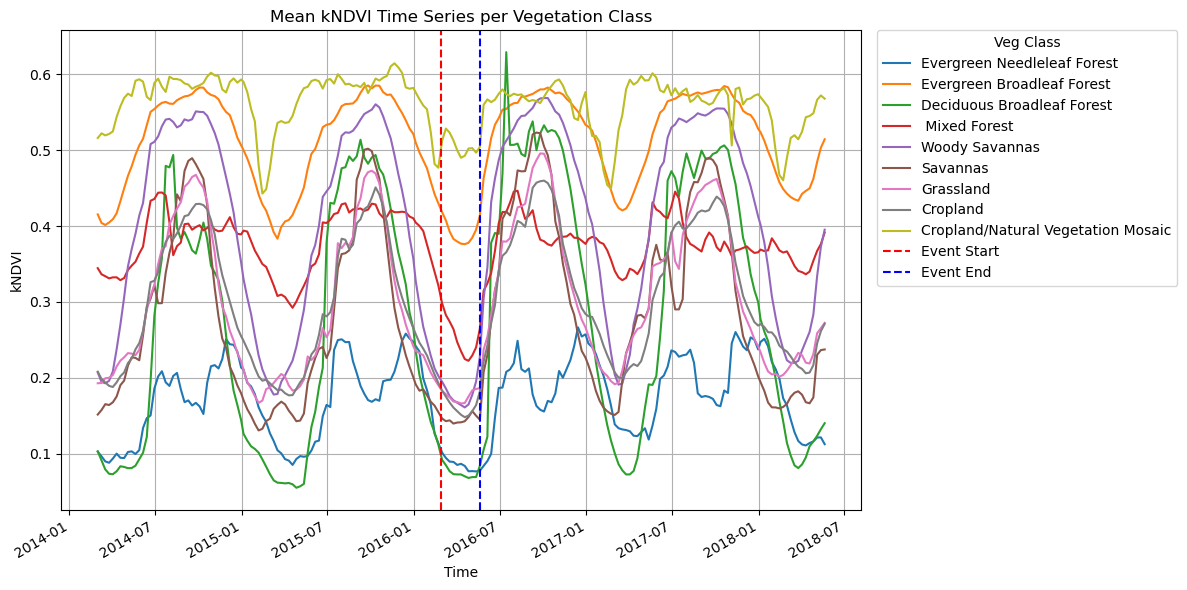

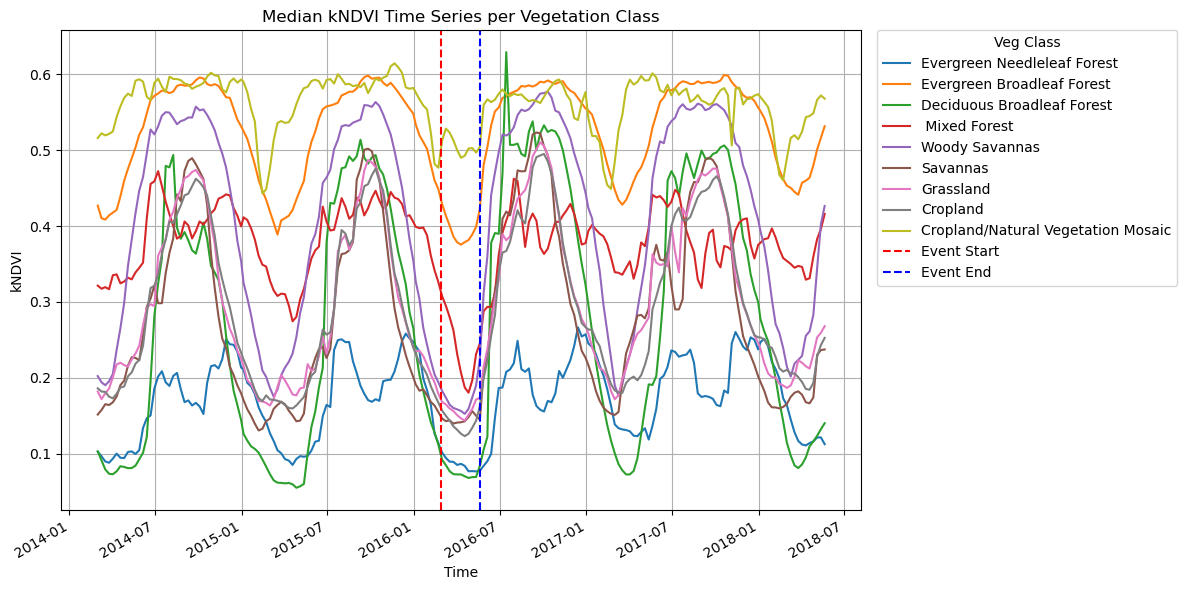

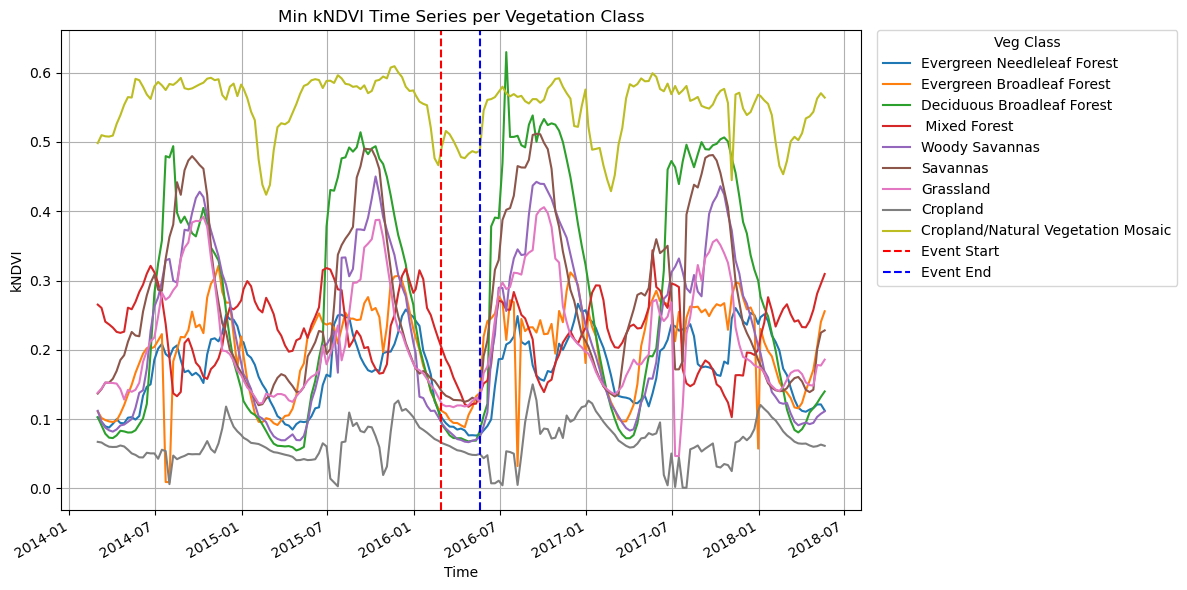

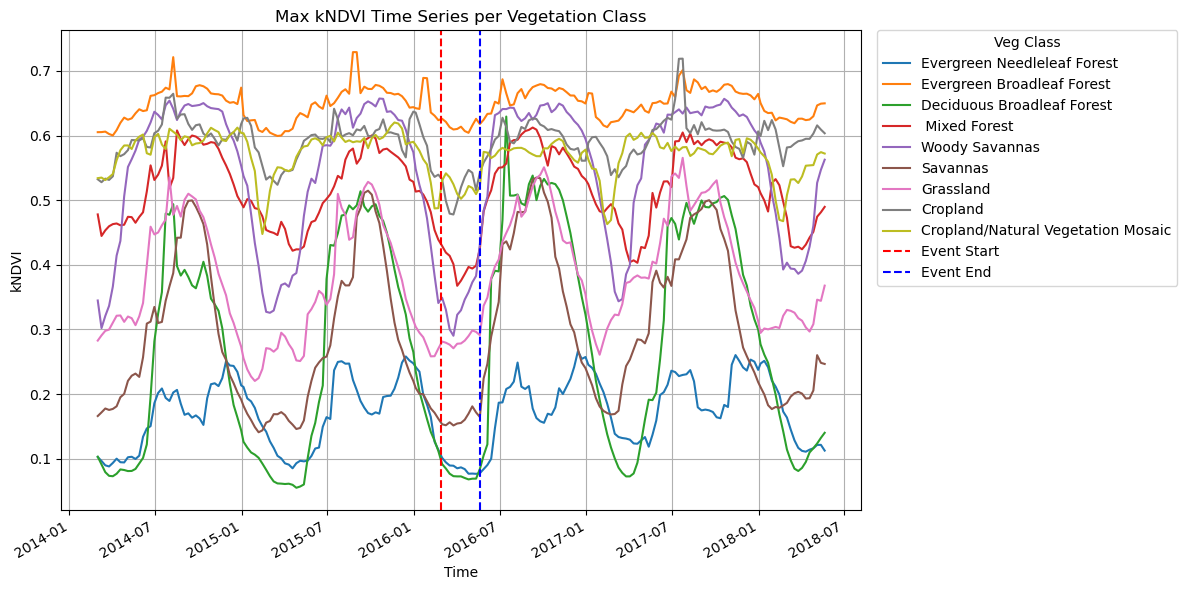

In [243]:
plot_aggregated_ts(df_105411_mean_kndvi_ts, start_time_value, end_time_value, method='Mean', df_translation=df_translation)
plot_aggregated_ts(df_105411_median_kndvi_ts, start_time_value, end_time_value, method='Median', df_translation=df_translation)
plot_aggregated_ts(df_105411_min_kndvi_ts, start_time_value, end_time_value, method='Min', df_translation=df_translation)
plot_aggregated_ts(df_105411_max_kndvi_ts, start_time_value, end_time_value, method='Max', df_translation=df_translation)

# 2. Calculate event statistics
## 2.1 Remove seasonality


Best hyperparameters found (already internally used by event_analysis.ts.ts_decomposition):
- inner_iter: 1
- outer_iter: 15
- seasonal: 45
- trend: 49

In [244]:
# Deseasonalize
df_105411_mean_kndvi_ts_deseasonalized = event_analysis.ts_decomposition(df_105411_mean_kndvi_ts, method='deseasonalized')

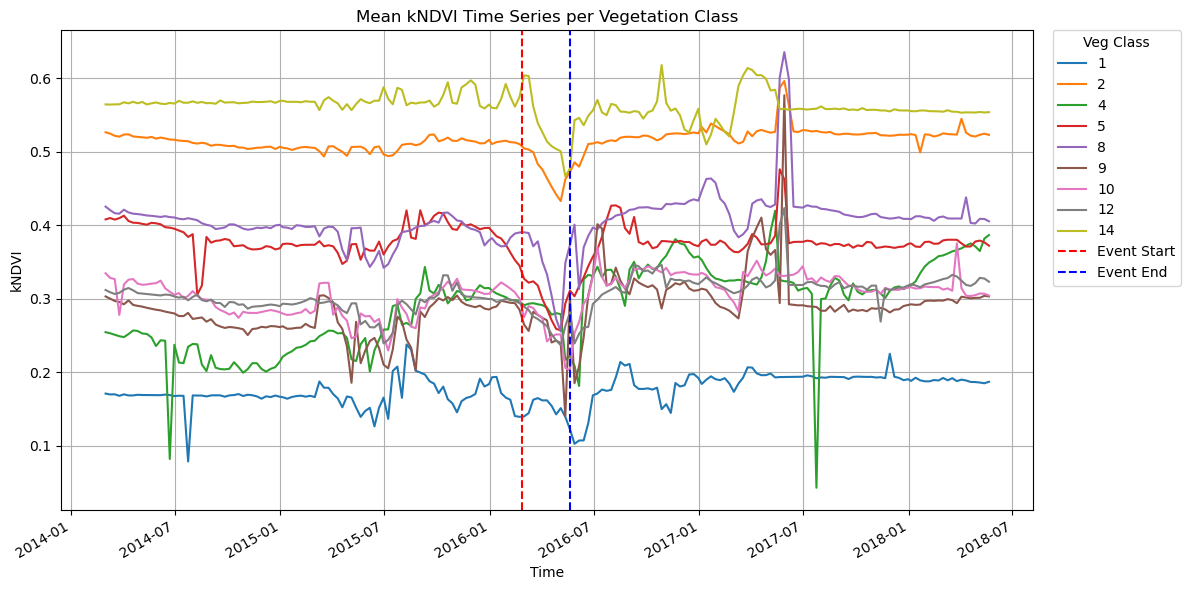

In [245]:
# Visualize
plot_aggregated_ts(df_105411_mean_kndvi_ts_deseasonalized, start_time_value, end_time_value, method='Mean')

## 2.2 Calculate event statistics for kNDVI

In [248]:
# Calculate event statistics for deseasonalized data
df_stats_deseasonalized = event_analysis.calculate_event_stats(df_105411_mean_kndvi_ts_deseasonalized, start_time_value, end_time_value)
df_stats_deseasonalized.T


,vpre,vdist,vpost,resilience,resistance,recovery
1,0.169355,0.122846,0.185988,1.098214,0.725374,-0.662231
2,0.510424,0.432792,0.523697,1.026004,0.847907,-0.757002
4,0.252165,0.216960,0.329977,1.308578,0.860388,-0.747371
5,0.382778,0.257083,0.377287,0.985654,0.671623,-0.551419
8,0.395365,0.255450,0.422219,1.067924,0.646112,-0.479343
9,0.271910,0.140666,0.307810,1.132027,0.517326,-0.350183
10,0.295656,0.202594,0.322275,1.090034,0.685235,-0.565553
12,0.295606,0.236870,0.319036,1.079264,0.801305,-0.719139
14,0.568701,0.466432,0.557659,0.980584,0.820170,-0.728942


## 3. Prepare predictors
This section aims to consolidate all predictor variables into one dataframe. This uncludes the following steps:
- loading of event characteristics (for spatiotempral masking)
- compute number of days affected
- loading of predictor variables (mostly from ESDC)
    - t2m mean, t2m max, t2m min
    - precipitation
    - soil moisture
    - evaporation
    - potential evaporation
    - SPEI
- stack dimensions of masked predictor variables, group by vegetation type
- create dataframe

Later, the target variables from step 2 will be added to this dataframe.

### 3.1 Load variables


In [232]:
# Load data arrays
t2m = ds_esdc['air_temperature_2m']
t2mmin = ds_esdc['min_air_temperature_2m']
t2mmax = ds_esdc['max_air_temperature_2m']
prec = ds_esdc['precipitation_era5']
soil_moist = ds_esdc['root_moisture']
evap = ds_esdc['evaporation']
evap_pot = ds_esdc['potential_evaporation']

# Create event arrays
t2m_array_105411 = es.create_event_dataarray(d_array = t2m, event_mask = event_mask_105411, event_label=105411, event_table=df_chd_filtered, time_buffer = 0)
t2mmin_array_105411 = es.create_event_dataarray(d_array = t2mmin, event_mask = event_mask_105411, event_label=105411, event_table=df_chd_filtered, time_buffer = 0)
t2mmax_array_105411 = es.create_event_dataarray(d_array = t2mmax, event_mask = event_mask_105411, event_label=105411, event_table=df_chd_filtered, time_buffer = 0)
prec_array_105411 = es.create_event_dataarray(d_array = prec, event_mask = event_mask_105411, event_label=105411, event_table=df_chd_filtered, time_buffer = 0)
soil_moist_array_105411 = es.create_event_dataarray(d_array = soil_moist, event_mask = event_mask_105411, event_label=105411, event_table=df_chd_filtered, time_buffer = 0)
evap_array_105411 = es.create_event_dataarray(d_array = evap, event_mask = event_mask_105411, event_label=105411, event_table=df_chd_filtered, time_buffer = 0)
evap_pot_array_105411 = es.create_event_dataarray(d_array = evap_pot, event_mask = event_mask_105411, event_label=105411, event_table=df_chd_filtered, time_buffer = 0)

### 3.2 Compute and aggregate predictors
#### Number of days affected

In [200]:
event_count_105411 = event_analysis.calculate_n_days_affected(start_time_value, end_time_value, event_mask_105411, event_label=105411, ds_label=ds_chd_labels) # Already tailored to specific event

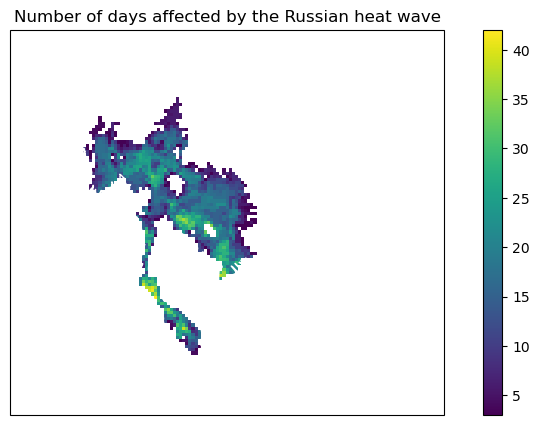

In [193]:
# Plot the event count array
plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
event_count_105411.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', add_colorbar=True)
ax.set_title("Number of days affected by the Russian heat wave")
ax.coastlines(color='white')
ax.set_extent([88, 123, -2, 28])
plt.show()

### 4. Put together target values and predictors

put all predictors in one df by adding columns

put all target values in same df by adding columns

put all events together by adding them as rows

In [256]:
event_count_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation, 
                                                                event_mask=event_mask_105411, 
                                                                data_array=event_count_105411, 
                                                                method='mean')
t2m_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=t2m_array_105411,
                                                   method='mean')
t2mmin_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=t2mmin_array_105411,
                                                   method='mean')
t2mmax_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=t2mmax_array_105411,
                                                   method='mean')
prec_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=prec_array_105411,
                                                   method='sum')
soil_moist_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=soil_moist_array_105411,
                                                   method='sum')
evap_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=evap_array_105411,
                                                   method='sum')
evap_pot_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=evap_pot_array_105411,
                                                   method='sum')

# Put series together as dataframe
df_105411 = pd.DataFrame({'n_days': event_count_agg_105411,
                           't2m': t2m_agg_105411,
                           't2mmin': t2mmin_agg_105411,
                           't2mmax': t2mmax_agg_105411,
                           'prec': prec_agg_105411,
                           'soil_moist': soil_moist_agg_105411,
                           'evap': evap_agg_105411,
                           'evap_pot': evap_pot_agg_105411})

# Add event stats to dataframe
df_105411 = df_105411.join(df_stats_deseasonalized.T)

# Add column with event label
df_105411['event_label'] = 105411

# Use vegetation type and event label as multiindex
df_105411 = df_105411.set_index(['event_label', df_105411.index])

# Drop rows with NaN values
df_105411 = df_105411.dropna()

df_105411

n_days        t2m     t2mmin     t2mmax  \
event_label veg_class                                               
105411      1.0        30.000000  27.139009  23.488594  32.088093   
            2.0        14.625683  25.553421  19.530460  33.274090   
            4.0        14.000000  28.390463  21.640602  37.605694   
            5.0        22.909091  26.906374  21.098267  34.087883   
            8.0        12.722772  27.802845  21.251038  35.736954   
            9.0         6.000000  27.250563  19.970627  35.077591   
            10.0       12.533333  27.991474  21.056370  35.716660   
            12.0       16.261324  29.102619  23.028124  36.485764   
            14.0       26.500000  29.139164  23.059013  36.624947   

                               prec   soil_moist          evap      evap_pot  \
event_label veg_class                                                          
105411      1.0           18.518827     3.432765     10.452525     43.961914   
            2.0        17911.517578  3608.300049  22570.041016  33767.300781   
            4.0           33.957005     6.241892     10.147535     45.488159   
            5.0          278.679840    97.798882    378.462738    630.061035   
            8.0         2412.464355  1005.397339   2398.776123   4975.884766   
            9.0           51.519447    22.896685     51.291283    101.484581   
            10.0         402.994293   197.902832    419.543030    828.549194   
            12.0       14753.416016  8028.097168  14512.898438  30392.507812   
            14.0          67.004211    33.993538     86.208336    108.838631   

                           vpre     vdist     vpost  resilience  resistance  \
event_label veg_class                                                         
105411      1.0        0.169355  0.122846  0.185988    1.098214    0.725374   
            2.0        0.510424  0.432792  0.523697    1.026004    0.847907   
            4.0        0.252165  0.216960  0.329977    1.308578    0.860388   
            5.0        0.382778  0.257083  0.377287    0.985654    0.671623   
            8.0        0.395365  0.255450  0.422219    1.067924    0.646112   
            9.0        0.271910  0.140666  0.307810    1.132027    0.517326   
            10.0       0.295656  0.202594  0.322275    1.090034    0.685235   
            12.0       0.295606  0.236870  0.319036    1.079264    0.801305   
            14.0       0.568701  0.466432  0.557659    0.980584    0.820170   

                       recovery  
event_label veg_class            
105411      1.0       -0.662231  
            2.0       -0.757002  
            4.0       -0.747371  
            5.0       -0.551419  
            8.0       -0.479343  
            9.0       -0.350183  
            10.0      -0.565553  
            12.0      -0.719139  
            14.0      -0.728942

## Playground: find out why some events have been skipped

In [3]:
skipped_kndvi_invalid = [89565, 86754, 86346, 103437, 89405, 86201, 73877, 102611, 104283, 79191, 86543, 74584, 90257, 104887, 119866, 73794, 72851, 112363, 105968, 89477, 63046, 100506, 117801, 105446, 103167, 73817, 63025, 73121, 117461, 117280, 86202, 99641, 110139, 76026, 79066, 120216, 119970, 104567, 81106, 102574, 115026, 121053, 109817, 97552, 74425, 66688, 67981, 102196, 86962, 79054, 96386, 100091, 120890, 76341, 66557, 60337, 81632]

In [100]:
# Columns to keep
columns_to_keep = [ 'label',
    'longitude_min', 'longitude_max',
    'latitude_min', 'latitude_max',
    'land_share', 'volume', 'area'
]

# Subset of events that made it through the process
excluded_labels = set(skipped_kndvi_invalid)

# Filter the DataFrame
df_subset_kndvi_skipped = df_chd_filtered[df_chd_filtered['label'].isin(skipped_kndvi_invalid)][columns_to_keep]
df_subset_valid = df_chd_filtered[~df_chd_filtered['label'].isin(excluded_labels)][columns_to_keep]

-> Examine these in data viewer

### Try to create masks for skipped events

In [220]:
importlib.reload(event_analysis)
importlib.reload(event_visualization)
importlib.reload(es)

<module 'utils.event_sampling' from '/Users/georgbrandt/Desktop/STUDIUM/Masterarbeit/repository/utils/event_sampling.py'>

In [225]:
event = skipped_kndvi_invalid[20]

mask = es.create_event_mask(event_label=event, 
                            event_table=df_chd_filtered, 
                            labelcube=ds_chd_labels, 
                            land_mask=landmask)

array = es.create_event_dataarray(kndvi, 
                                mask, 
                                df_chd_filtered, 
                                event, 
                                time_buffer=buffer)

array

<xarray.DataArray 'kndvi' (time: 1487, lat: 78, lon: 73)> Size: 34MB
dask.array<getitem, shape=(1487, 78, 73), dtype=float32, chunksize=(1, 78, 73), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 624B 11.88 12.12 12.38 12.62 ... 30.62 30.88 31.12
  * lon      (lon) float64 584B -110.4 -110.1 -109.9 ... -92.88 -92.62 -92.38
  * time     (time) datetime64[ns] 12kB 2001-04-27 2001-04-27 ... 2005-05-21
Attributes: (12/25)
    acknowledgment:             https://lpdaac.usgs.gov/products/mcd43c4v061/
    date_modified:              2022-10-11 23:51:00.603768
    description:                MODIS/Terra+Aqua BRDF/Albedo Nadir BRDF-Adjus...
    geospatial_lat_max:         89.875
    geospatial_lat_min:         -89.87499999998977
    geospatial_lat_resolution:  0.25
    ...                         ...
    standard_name:              kNDVI
    temporal_resolution:        8D
    time_coverage_end:          2021-12-31T00:00:00.000000000
    time_coverage_start:        2000-03-01T00:00:00.000000000
    time_period:                8D
    units:                      1

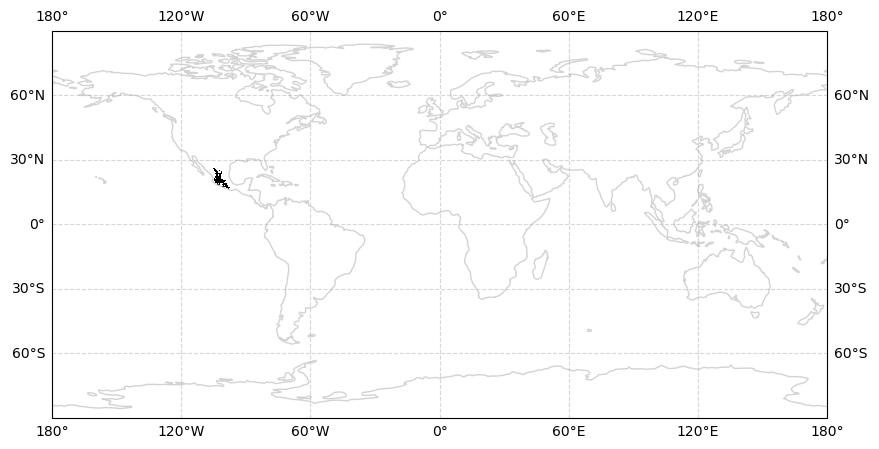

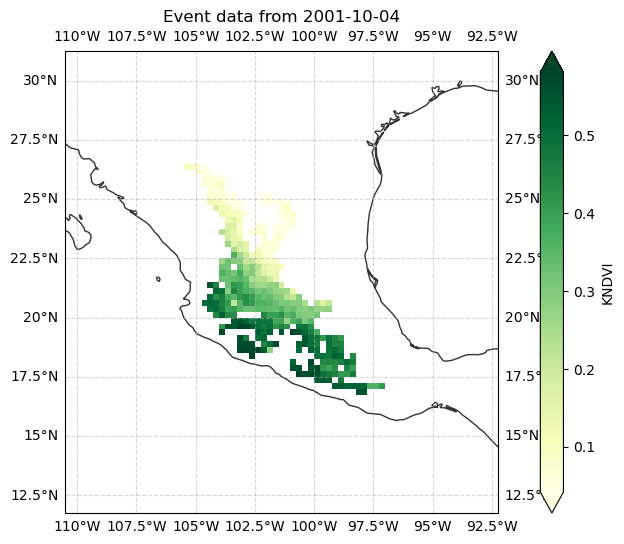

In [226]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6),
                subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the mask
mask.plot(ax=ax, transform=ccrs.PlateCarree(), 
        cmap='Greys', add_colorbar=False)

# Add geographic features
ax.coastlines(color='lightgrey')

# Optional: Add gridlines
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

plt.show()   


# Evetn day
event_visualization.plot_event_day(array, 20)